In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

In [2]:
df = pd.read_csv('Merged_SoilMoisture_Data.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Points: {df['Point_ID'].nunique()}  |  Dates: {df['Date'].nunique()}")

Loaded: 401 rows × 17 columns
Points: 100  |  Dates: 22


In [4]:
def engineer_features(df):
    df = df.copy()
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
    #  Fix 3 missing SAR values (spatial median per point) 
    for col in ['VV_500m', 'VH_500m', 'Angle_500m']:
        null_mask = df[col].isnull()
        if null_mask.sum() > 0:
            fill = df.groupby('Point_ID')[col].transform('median')
            df.loc[null_mask, col] = fill[null_mask]
 
    #  SAR physics features 
    df['VV_linear']  = 10 ** (df['VV_500m'] / 10)   # dB → linear
    df['VH_linear']  = 10 ** (df['VH_500m'] / 10)
    df['VV_VH_diff'] = df['VV_500m'] - df['VH_500m']
 
    #  Terrain interaction features 
    df['slope_elev']  = df['Elevation_m'] / (df['Slope'] + 0.1)
    df['rough_slope'] = df['Roughness'] * df['Slope']
 
    df['VV_x_season'] = df['VV_linear'] * df['month_sin']
    df['VH_x_season'] = df['VH_linear'] * df['month_sin']
    df['VV_x_cos']    = df['VV_linear'] * df['month_cos']
    df['VH_x_cos']    = df['VH_linear'] * df['month_cos']
    df['sin_doy'] = np.sin(2*np.pi*df['doy']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['doy']/365)
    # Dual polarization power
    df['total_power'] = df['VV_linear'] + df['VH_linear']

    # Polarization entropy proxy
    df['pol_entropy'] = -( (df['VV_linear']/(df['VV_linear']+df['VH_linear'])) * 
                        np.log(df['VV_linear']/(df['VV_linear']+df['VH_linear'])) )
    df['northness']      = np.cos(np.radians(df['Aspect']))
    df['eastness']       = np.sin(np.radians(df['Aspect']))
 
    return df
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear

df = engineer_features(df)
 

In [17]:
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from lightgbm import LGBMRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── FEATURES ────────────────────────────────────────────────────────────────

FEATURES = [
    'doy',
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    'CR=VH/VV', 'RVI', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    'Elevation_m', 'Slope', 'Roughness',
    'slope_elev', 'rough_slope',
    'VV_x_season', 'VH_x_season', 'VV_x_cos', 'VH_x_cos',
    'sin_doy', 'cos_doy', 'pol_entropy', 'northness', 'eastness'
]

# ── EXTRA INTERACTION FEATURES ──────────────────────────────────────────────

df = df.sort_values(['Point_ID', 'doy']).reset_index(drop=True)

df['VV_x_elev']      = df['VV_500m']   * df['Elevation_m']
df['RVI_x_slope']    = df['RVI']       * df['Slope']
df['CR_x_doy']       = df['CR=VH/VV'] * df['sin_doy']

df['VV_rolling_std']  = df.groupby('Point_ID')['VV_500m'].transform(
                            lambda x: x.rolling(3, min_periods=2).std()).fillna(0)
df['VH_rolling_mean'] = df.groupby('Point_ID')['VH_500m'].transform(
                            lambda x: x.rolling(3, min_periods=2).mean()).fillna(
                            df['VH_500m'])

EXTRA = ['VV_x_elev', 'RVI_x_slope', 'CR_x_doy', 'VV_rolling_std', 'VH_rolling_mean']

ALL_FEATURES = FEATURES + EXTRA

X = df[shapfeatures].copy()
y = df['Observed_SM'].copy()

# ── SPATIAL TRAIN / TEST SPLIT ───────────────────────────────────────────────

np.random.seed(42)
test_pts   = np.random.choice(df['Point_ID'].unique(), size=20, replace=False)
train_mask = ~df['Point_ID'].isin(test_pts)
test_mask  =  df['Point_ID'].isin(test_pts)

X_train_df   = X[train_mask].reset_index(drop=True)
y_train_s    = y[train_mask].reset_index(drop=True)
groups_train = df.loc[train_mask, 'Point_ID'].reset_index(drop=True).values

X_test_df    = X[test_mask].reset_index(drop=True)
y_test_s     = y[test_mask].reset_index(drop=True)

scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_test_sc  = scaler.transform(X_test_df)

y_train = y_train_s.values
y_test  = y_test_s.values

gkf = GroupKFold(n_splits=5)

# ── METRICS ──────────────────────────────────────────────────────────────────

def full_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    r    = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  R²   : {r2:.4f}")
    print(f"  R    : {r:.4f}")
    print(f"  RMSE : {rmse:.4f} m³/m³")
    print(f"  MAE  : {mae:.4f} m³/m³")
    print(f"  Bias : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, mae=mae, bias=bias)

# ── OPTUNA — LightGBM ────────────────────────────────────────────────────────

print("\nTuning LightGBM with Optuna...")

def lgbm_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 200, 800),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 10, 80),
        max_depth         = trial.suggest_int('max_depth', 3, 7),
        min_child_samples = trial.suggest_int('min_child_samples', 20, 80),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.5, 20.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 30.0),
    )

    fold_scores = []
    for tr_idx, val_idx in gkf.split(X_train_df, y_train_s, groups_train):
        X_tr  = X_train_df.iloc[tr_idx].values
        X_val = X_train_df.iloc[val_idx].values
        y_tr  = y_train_s.iloc[tr_idx].values
        y_val = y_train_s.iloc[val_idx].values

        sc       = RobustScaler()
        X_tr_sc  = sc.fit_transform(X_tr)
        X_val_sc = sc.transform(X_val)

        model = LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
        model.fit(X_tr_sc, y_tr)
        fold_scores.append(r2_score(y_val, model.predict(X_val_sc)))

    return np.mean(fold_scores)

study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_lgbm.optimize(lgbm_objective, n_trials=200, show_progress_bar=True)

print(f"\nLGBM best CV R² : {study_lgbm.best_value:.4f}")
print(f"LGBM best params : {study_lgbm.best_params}")

# ── TRAIN FINAL MODEL ────────────────────────────────────────────────────────

best_lgbm_params = study_lgbm.best_params.copy()

best_lgbm = LGBMRegressor(**best_lgbm_params, random_state=42, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train_sc, y_train)

print("\nEvaluating LightGBM...")

train_pred = best_lgbm.predict(X_train_sc)
test_pred  = best_lgbm.predict(X_test_sc)

train_m = full_metrics(y_train, train_pred, "LIGHTGBM TRAIN")
test_m  = full_metrics(y_test,  test_pred,  "LIGHTGBM TEST (spatial holdout)")

# ── 5-FOLD SPATIAL CV ────────────────────────────────────────────────────────

print(f"\n{'─'*40}")
print("  5-FOLD SPATIAL CV (LIGHTGBM)")
print(f"{'─'*40}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, val_idx) in enumerate(
        gkf.split(X_train_df, y_train_s, groups_train), 1):

    X_tr  = X_train_df.iloc[tr_idx].values
    X_val = X_train_df.iloc[val_idx].values
    y_tr  = y_train[tr_idx]
    y_val = y_train[val_idx]

    sc       = RobustScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_val_sc = sc.transform(X_val)

    model = LGBMRegressor(
        **study_lgbm.best_params,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_tr_sc, y_tr)
    pred = model.predict(X_val_sc)

    fold_r2.append(r2_score(y_val, pred))
    fold_rmse.append(np.sqrt(mean_squared_error(y_val, pred)))
    fold_mae.append(mean_absolute_error(y_val, pred))

    print(
        f"Fold {fold} → "
        f"R²={fold_r2[-1]:.4f}  "
        f"RMSE={fold_rmse[-1]:.4f}  "
        f"MAE={fold_mae[-1]:.4f}"
    )

print(f"{'─'*40}")
print(
    f"Mean → "
    f"R²={np.mean(fold_r2):.4f}  "
    f"RMSE={np.mean(fold_rmse):.4f}  "
    f"MAE={np.mean(fold_mae):.4f}"
)
print(
    f"Std  → "
    f"R²={np.std(fold_r2):.4f}  "
    f"RMSE={np.std(fold_rmse):.4f}  "
    f"MAE={np.std(fold_mae):.4f}"
)


Tuning LightGBM with Optuna...


  0%|          | 0/200 [00:00<?, ?it/s]


LGBM best CV R² : 0.3175
LGBM best params : {'n_estimators': 641, 'learning_rate': 0.04309356381739167, 'num_leaves': 12, 'max_depth': 6, 'min_child_samples': 28, 'subsample': 0.9826024940678558, 'colsample_bytree': 0.7259544197286092, 'reg_alpha': 0.8885138600459582, 'reg_lambda': 12.639726423470387}

Evaluating LightGBM...

────────────────────────────────────────
  LIGHTGBM TRAIN
────────────────────────────────────────
  R²   : 0.5396
  R    : 0.7666
  RMSE : 0.0544 m³/m³
  MAE  : 0.0430 m³/m³
  Bias : -0.0006 m³/m³

────────────────────────────────────────
  LIGHTGBM TEST (spatial holdout)
────────────────────────────────────────
  R²   : 0.3515
  R    : 0.6170
  RMSE : 0.0707 m³/m³
  MAE  : 0.0548 m³/m³
  Bias : -0.0020 m³/m³

────────────────────────────────────────
  5-FOLD SPATIAL CV (LIGHTGBM)
────────────────────────────────────────
Fold 1 → R²=0.2883  RMSE=0.0719  MAE=0.0525
Fold 2 → R²=0.3463  RMSE=0.0610  MAE=0.0469
Fold 3 → R²=0.3175  RMSE=0.0587  MAE=0.0485
Fold 4 → R²

Computing SHAP for LightGBM...

Top 20 SHAP Features
cos_doy           0.134511
slope_elev        0.118035
sin_doy           0.101876
VV_x_elev         0.067484
MPI               0.062385
VH_x_season       0.050039
VH_x_cos          0.045399
CR_x_doy          0.039649
VV_x_cos          0.037501
VV_500m           0.035992
VV_rolling_std    0.030862
Slope             0.028573
doy               0.027645
Elevation_m       0.027625
VV_x_season       0.027237
northness         0.022790
VV_linear         0.022556
Angle_500m        0.020470
VH_500m           0.019273
eastness          0.017604
dtype: float64


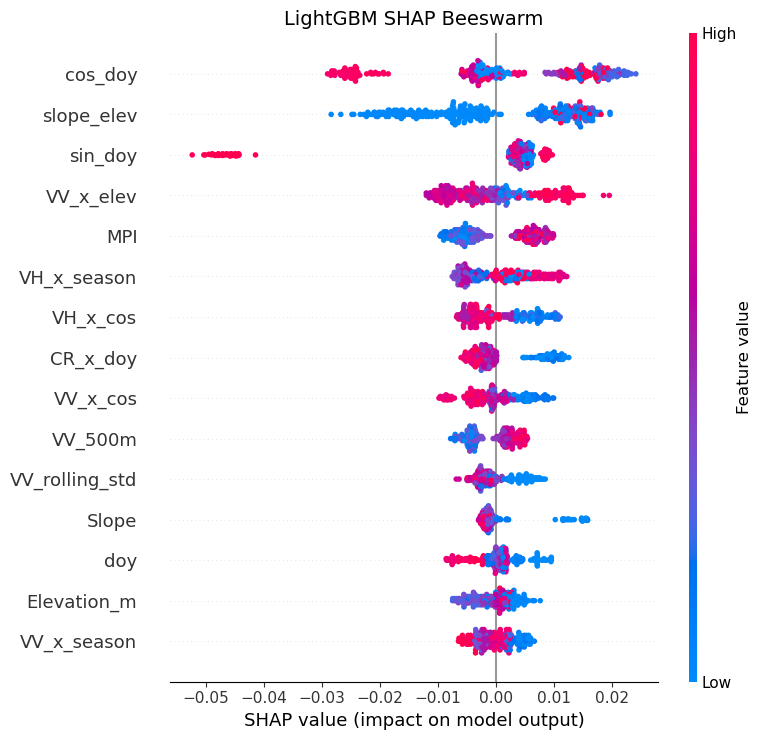

In [15]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# SHAP FOR LIGHTGBM
# =====================================================

print("Computing SHAP for LightGBM...")

explainer_lgbm = shap.TreeExplainer(best_lgbm)

shap_lgbm = explainer_lgbm.shap_values(X_train_sc)

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

shap_importance = np.abs(shap_lgbm).mean(axis=0)
shap_importance = shap_importance / shap_importance.sum()

imp_series = pd.Series(
    shap_importance,
    index=ALL_FEATURES
).sort_values(ascending=False)

print("\nTop 20 SHAP Features")
print(imp_series.head(20))

# =====================================================
# BEESWARM
# =====================================================

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_lgbm,
    X_train_sc,
    feature_names=ALL_FEATURES,
    max_display=15,
    show=False
)

plt.title("LightGBM SHAP Beeswarm", fontsize=14)

plt.tight_layout()
plt.show()

In [16]:
shapfeatures= imp_series.sort_values(ascending=False).head(12).index.tolist()